# kNN Baseline

Simple kNN baseline for the everyday objects category using Google Quick, Draw!
1. Loads categories from `../../categories/objects.txt`
2. Loads Quick, Draw! sketches
3. Converts drawings into 28x28 grayscale images
4. Flattens each image into a 1D vector
5. Trains a kNN classifier
6. Saves accuracy, confusion matrix, and example prediction visuals

In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from quickdraw import QuickDrawDataGroup

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
SEED = 42
SAMPLES_PER_CATEGORY = 200
IMAGE_SIZE = 28
K_NEIGHBORS = 5

CATEGORY_FILE = Path("../../categories/objects.txt")
RESULTS_DIR = Path("objects_knn_results")
RESULTS_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

print("Setup complete")

Setup complete


## Load category names

The category file contains the everyday object labels for this model.

In [3]:
with open(CATEGORY_FILE, "r") as f:
    text = f.read()

categories = [
    category.strip()
    for category in text.replace("\n", ",").split(",")
    if category.strip()
]

label_map = {category: index for index, category in enumerate(categories)}
reverse_label_map = {index: category for category, index in label_map.items()}

print("Number of categories:", len(categories))
print(categories)

Number of categories: 23
['backpack', 'bed', 'book', 'calendar', 'cell phone', 'chair', 'clock', 'computer', 'couch', 'cup', 'door', 'dresser', 'fan', 'key', 'knife', 'laptop', 'microwave', 'shoe', 'spoon', 'table', 'television', 'toilet', 'toothbrush']


## Convert drawings into image arrays

Each Quick, Draw! sketch is converted into a 28x28 grayscale image.

The image is inverted so the drawing strokes are bright and the background is dark.

In [4]:
def drawing_to_array(drawing, image_size=28):
    image = drawing.image
    
    # Convert to grayscale
    image = image.convert("L")
    
    # Resize to 28x28
    image = image.resize((image_size, image_size), Image.Resampling.LANCZOS)
    
    # Convert to numpy array
    array = np.array(image).astype(np.float32)
    
    # Invert so drawing lines become bright values
    array = 255.0 - array
    
    # Normalize values to 0-1
    array = array / 255.0
    
    return array

## Build dataset

This cell loads Quick, Draw! sketches for every object category.

In [5]:
X = []
y = []

for category in categories:
    print(f"Loading {category}...")
    
    group = QuickDrawDataGroup(
        category,
        max_drawings=SAMPLES_PER_CATEGORY,
        print_messages=False
    )
    
    count = 0
    
    for drawing in group.drawings:
        array = drawing_to_array(drawing, IMAGE_SIZE)
        
        X.append(array)
        y.append(label_map[category])
        
        count += 1
        
        if count >= SAMPLES_PER_CATEGORY:
            break
    
    print(f"Loaded {count} drawings for {category}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading backpack...
Loaded 200 drawings for backpack
Loading bed...
Loaded 200 drawings for bed
Loading book...
Loaded 200 drawings for book
Loading calendar...
Loaded 200 drawings for calendar
Loading cell phone...
Loaded 200 drawings for cell phone
Loading chair...
Loaded 200 drawings for chair
Loading clock...
Loaded 200 drawings for clock
Loading computer...
Loaded 200 drawings for computer
Loading couch...
Loaded 200 drawings for couch
Loading cup...
Loaded 200 drawings for cup
Loading door...
Loaded 200 drawings for door
Loading dresser...
Loaded 200 drawings for dresser
Loading fan...
Loaded 200 drawings for fan
Loading key...
Loaded 200 drawings for key
Loading knife...
Loaded 200 drawings for knife
Loading laptop...
Loaded 200 drawings for laptop
Loading microwave...
Loaded 200 drawings for microwave
Loading shoe...
Loaded 200 drawings for shoe
Loading spoon...
Loaded 200 drawings for spoon
Loading table...
Loaded 200 drawings for table
Loading television...
Loaded 200 drawing

## Preview drawings

This checks that the drawings loaded correctly.

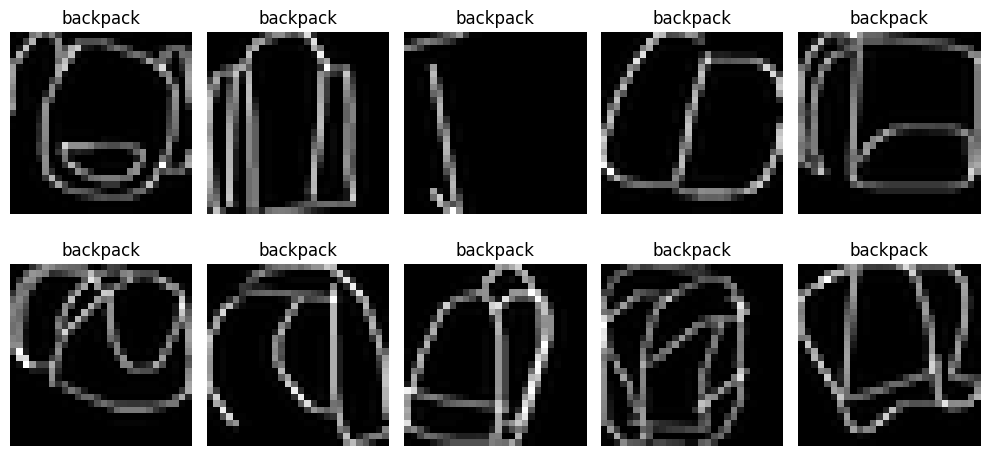

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(reverse_label_map[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Prepare data for kNN

kNN cannot use 2D images directly.

Each 28x28 image is flattened into a vector of 784 pixel values.

In [7]:
X_flat = X.reshape(X.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Flattened data shape:", X_flat.shape)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Flattened data shape: (4600, 784)
Training data: (3680, 784)
Testing data: (920, 784)


## Train kNN model

This trains a kNN classifier using 5 nearest neighbors.

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=K_NEIGHBORS)

print("Training kNN...")
knn_model.fit(X_train, y_train)

print("kNN training complete")

Training kNN...
kNN training complete


## Evaluate kNN model

Accuracy tells us what percentage of test drawings the kNN model classified correctly.

In [9]:
knn_predictions = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print(f"kNN accuracy: {knn_accuracy:.4f}")
print(f"kNN accuracy percentage: {knn_accuracy * 100:.2f}%")

kNN accuracy: 0.2989
kNN accuracy percentage: 29.89%


## Classification report

This shows precision, recall, and F1-score for each object category.

In [11]:
report = classification_report(
    y_test,
    knn_predictions,
    target_names=categories
)

print(report)

              precision    recall  f1-score   support

    backpack       0.20      0.03      0.04        40
         bed       0.15      0.38      0.22        40
        book       0.56      0.12      0.20        40
    calendar       0.00      0.00      0.00        40
  cell phone       0.35      0.30      0.32        40
       chair       0.26      0.70      0.38        40
       clock       0.72      0.70      0.71        40
    computer       0.26      0.12      0.17        40
       couch       0.55      0.40      0.46        40
         cup       0.30      0.07      0.12        40
        door       0.23      0.53      0.32        40
     dresser       0.08      0.03      0.04        40
         fan       0.83      0.12      0.22        40
         key       0.50      0.15      0.23        40
       knife       0.34      0.40      0.37        40
      laptop       0.42      0.12      0.19        40
   microwave       0.48      0.57      0.52        40
        shoe       0.43    

<Figure size 1200x1200 with 0 Axes>

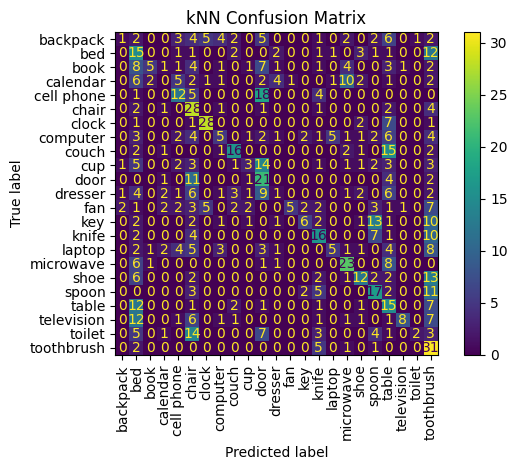

In [12]:
#confusion matrix
cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(12, 12))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)

display.plot(xticks_rotation=90, values_format="d")
plt.title("kNN Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_confusion_matrix.png")
plt.show()

## Example predictions

This shows some test drawings with their true labels and predicted labels.

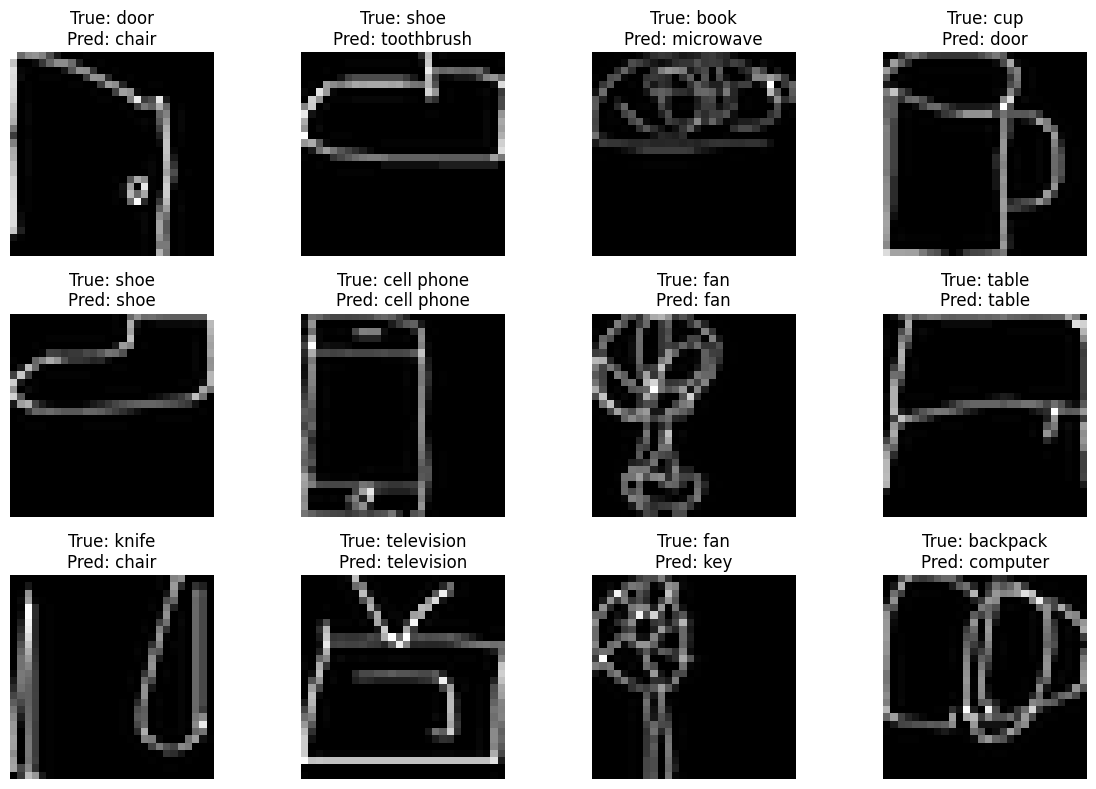

In [13]:
plt.figure(figsize=(12, 8))

# Reshape test images back to 28x28 for viewing
X_test_images = X_test.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

for i in range(12):
    true_label = y_test[i]
    predicted_label = knn_predictions[i]
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_images[i], cmap="gray")
    plt.title(
        f"True: {reverse_label_map[true_label]}\n"
        f"Pred: {reverse_label_map[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_example_predictions.png")
plt.show()

## Save kNN accuracy result

This saves the final kNN accuracy into a text file so it can be referenced later.

In [14]:
with open(RESULTS_DIR / "knn_results.txt", "w") as f:
    f.write("Everyday Objects kNN Baseline Results\n")
    f.write("------------------------------------\n")
    f.write(f"Samples per category: {SAMPLES_PER_CATEGORY}\n")
    f.write(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}\n")
    f.write(f"k neighbors: {K_NEIGHBORS}\n")
    f.write(f"kNN accuracy: {knn_accuracy:.4f}\n")
    f.write(f"kNN accuracy percentage: {knn_accuracy * 100:.2f}%\n")

print("Saved results to:", RESULTS_DIR / "knn_results.txt")

Saved results to: objects_knn_results/knn_results.txt
